<a href="https://colab.research.google.com/github/irajamuller/shor_code/blob/main/shor_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalação e Carregamento de bibliotecas

In [1]:
!pip install qiskit qiskit_aer pylatexenc --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 92.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.5 MB/s eta 0:00:00


In [2]:
# Classes do qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator, Aer
from qiskit.visualization import plot_histogram, array_to_latex

import numpy as np

# Diagrama utilizado na implementação do Circuito Quântico
### Fonte: https://pennylane.ai/challenges/a_shor_thing

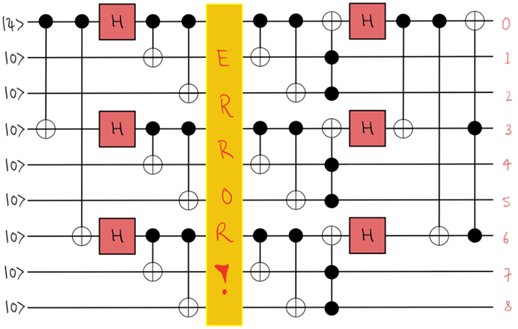

# Funções para a Codificação de Shor

In [3]:
def encode(qc, d):
  qc.barrier(label='Encode')
  # Phase-flip layer
  qc.cx(d[0], d[3]); qc.cx(d[0], d[6])
  qc.h(d[0]); qc.h(d[3]); qc.h(d[6])

  # Bit-flip layers (3 blocos)
  qc.cx(d[0], d[1]); qc.cx(d[0], d[2])
  qc.cx(d[3], d[4]); qc.cx(d[3], d[5])
  qc.cx(d[6], d[7]); qc.cx(d[6], d[8])

def inject_error(qc, d, errors):
  if not errors:
      return
  qc.barrier(label="Error")
  for qubit, etype in errors:
      if etype in ('X', 'Y'):
          qc.x(d[qubit])
      if etype in ('Z', 'Y'):
          qc.z(d[qubit])

def measure_syndrome_x(qc, d, a, s0, s1, s2):
  qc.barrier(label='Syndrom X')
  # Bloco 1
  qc.cx(d[0], a[0]); qc.cx(d[1], a[0])   # paridade d0⊕d1
  qc.cx(d[1], a[1]); qc.cx(d[2], a[1])   # paridade d1⊕d2
  # Bloco 2
  qc.cx(d[3], a[2]); qc.cx(d[4], a[2])   # paridade d3⊕d4
  qc.cx(d[4], a[3]); qc.cx(d[5], a[3])   # paridade d4⊕d5
  # Bloco 3
  qc.cx(d[6], a[4]); qc.cx(d[7], a[4])   # paridade d6⊕d7
  qc.cx(d[7], a[5]); qc.cx(d[8], a[5])   # paridade d7⊕d8

  qc.measure(a[0], s0[0]); qc.measure(a[1], s0[1])
  qc.measure(a[2], s1[0]); qc.measure(a[3], s1[1])
  qc.measure(a[4], s2[0]); qc.measure(a[5], s2[1])

def measure_syndrome_z(qc, d, a, sz):
  qc.barrier(label='Syndrom Z')
  # Paridade Z entre bloco 0 (d[0]) e bloco 1 (d[3])
  qc.h(a[0])
  qc.cx(d[0], a[0]); qc.cx(d[3], a[0])  # dados → ancilla (alvo)
  qc.h(a[0])

  # Paridade Z entre bloco 1 (d[3]) e bloco 2 (d[6])
  qc.h(a[1])
  qc.cx(d[3], a[1]); qc.cx(d[6], a[1])  # dados → ancilla (alvo)
  qc.h(a[1])

  qc.measure(a[0], sz[0])  # sz[0] = paridade bloco 0↔1
  qc.measure(a[1], sz[1])  # sz[1] = paridade bloco 1↔2

def correct_x(qc, d, s0, s1, s2):
  qc.barrier(label='Correction X')
  # Bloco 0
  with qc.if_test((s0, 1)): qc.x(d[0])   # ← era 3, correto é 1
  with qc.if_test((s0, 3)): qc.x(d[1])   # ← era 1, correto é 3
  with qc.if_test((s0, 2)): qc.x(d[2])   # ✓ mantém
  # Bloco 1
  with qc.if_test((s1, 1)): qc.x(d[3])   # ← era 3, correto é 1
  with qc.if_test((s1, 3)): qc.x(d[4])   # ← era 1, correto é 3
  with qc.if_test((s1, 2)): qc.x(d[5])   # ✓ mantém
  # Bloco 2
  with qc.if_test((s2, 1)): qc.x(d[6])   # ← era 3, correto é 1
  with qc.if_test((s2, 3)): qc.x(d[7])   # ← era 1, correto é 3
  with qc.if_test((s2, 2)): qc.x(d[8])   # ✓ mantém

def correct_z(qc, d, sz):
  qc.barrier(label='Correction Z')

  # Tabela de síndrome (sz[1] sz[0]):
  #   01 (=1) → erro no bloco 0 → corrige d[0]
  #   11 (=3) → erro no bloco 1 → corrige d[3]
  #   10 (=2) → erro no bloco 2 → corrige d[6]
  with qc.if_test((sz, 1)): qc.z(d[0])  # bloco 0
  with qc.if_test((sz, 3)): qc.z(d[3])  # bloco 1
  with qc.if_test((sz, 2)): qc.z(d[6])  # bloco 2

def decode(qc, d):
  qc.barrier(label='Decode')
  # 1. Desfaz bit-flip de cada bloco
  qc.cx(d[0], d[2]); qc.cx(d[0], d[1]); qc.ccx(d[2], d[1], d[0])
  qc.cx(d[3], d[5]); qc.cx(d[3], d[4]); qc.ccx(d[5], d[4], d[3])
  qc.cx(d[6], d[8]); qc.cx(d[6], d[7]); qc.ccx(d[8], d[7], d[6])

  # 3. Desfaz Hadamard
  qc.h(d[0]); qc.h(d[3]); qc.h(d[6])

  # 4. Majority vote
  qc.cx(d[0], d[6])   # inverso do último cx do encode
  qc.cx(d[0], d[3])   # inverso do primeiro cx do encode
  qc.ccx(d[3], d[6], d[0])  # Toffoli: d[0] = voto majoritário

def create_circuit(psi, errors):
  q_psi = QuantumRegister(1, 'psi')
  q_codes = QuantumRegister(8, 'code')
  q_all = [q_psi[0]] + [q_codes[i] for i in range(8)]

  q_ancilla_x = QuantumRegister(6, 'ancilla_x')
  q_ancilla_z = QuantumRegister(2, 'ancilla_z')

  c_syndromes0 = ClassicalRegister(2, name='syndrom b0')   # síndrome bloco 0
  c_syndromes1 = ClassicalRegister(2, name='syndrom b1')   # síndrome bloco 1
  c_syndromes2 = ClassicalRegister(2, name='syndrom b2')   # síndrome bloco 2
  c_syndromes_z = ClassicalRegister(2, name='syndrom z')   # síndrome Z

  logical_bit = ClassicalRegister(1, 'logical bit')

  qc = QuantumCircuit(q_psi, q_codes, q_ancilla_x, q_ancilla_z, c_syndromes0, c_syndromes1, c_syndromes2, c_syndromes_z, logical_bit)
  qc.barrier(label="Initial state")

  qc.initialize([1, 0] if psi == '0' else [0, 1], q_psi[0])

  # Encode
  encode(qc, q_all)

  # Inject Error
  inject_error(qc, q_all, errors)

  # Measure, and correction X errors
  measure_syndrome_x(qc, q_all, q_ancilla_x, c_syndromes0, c_syndromes1, c_syndromes2)
  correct_x(qc, q_all, c_syndromes0, c_syndromes1, c_syndromes2)

  # Measure, and correction Z errors
  measure_syndrome_z(qc, q_all, q_ancilla_z, c_syndromes_z)
  correct_z(qc, q_all, c_syndromes_z)

  # Decode
  decode(qc, q_all)

  qc.barrier(label='fim')
  qc.measure(q_psi[0], logical_bit[0])

  return qc

# Criação do Circuito Quântico (somente para testes)

In [ ]:
# Inicializa circuito com estado psi para enviar
qc = create_circuit('0', [(1,'X')])

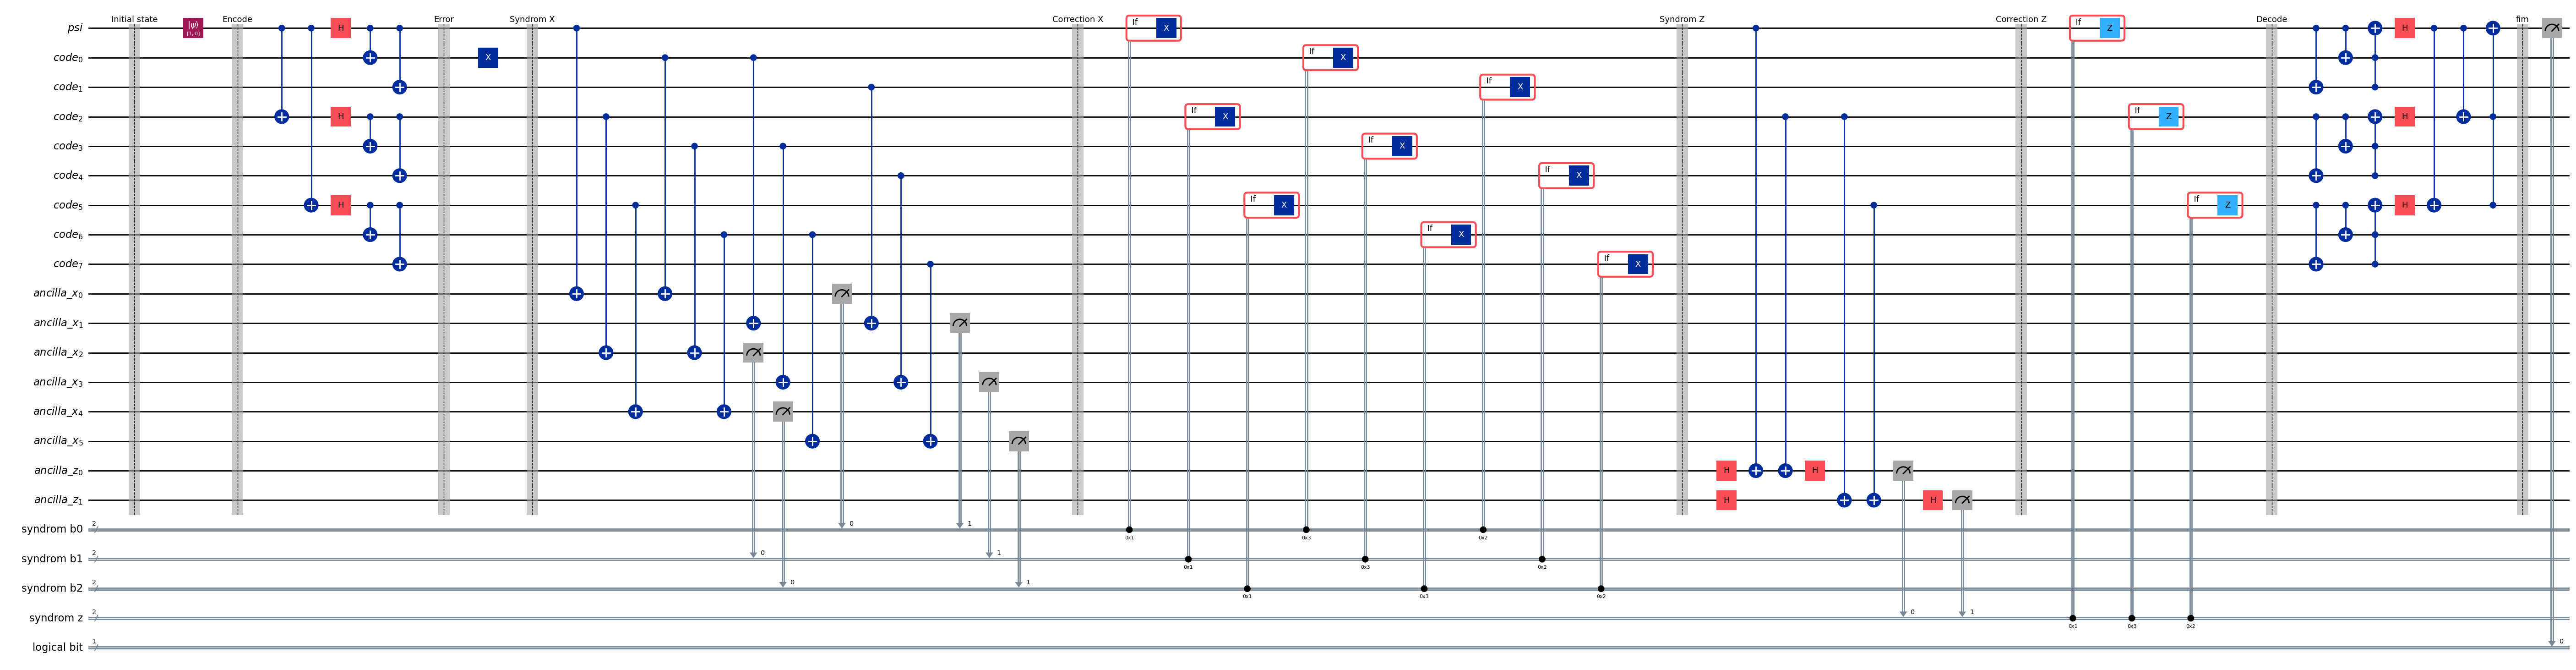

In [ ]:
qc.draw('mpl', fold=-1)

# Estado Antes da Medição (somente para testes)

In [ ]:
qc.remove_final_measurements()
backend = Aer.get_backend('statevector_simulator')
result = backend.run(qc).result()
final_state = result.get_statevector()

# 4. Ver as amplitudes
final_state.draw('latex')

<IPython.core.display.Latex object>

# Execução do Algoritmo (somente para testes)

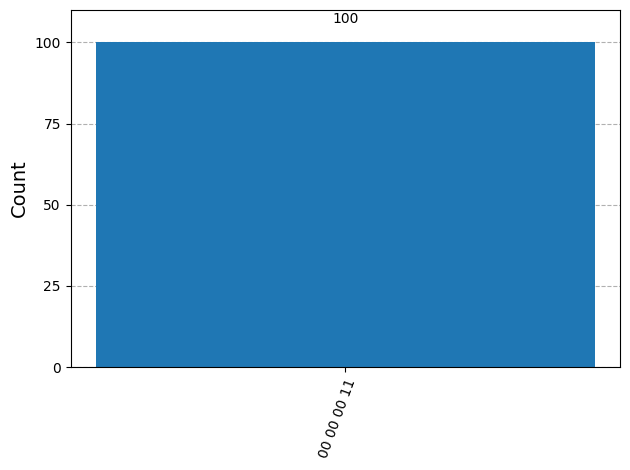

In [ ]:
qc_t = transpile(qc)
backend = AerSimulator()

result = backend.run(qc_t.decompose(reps=4), shots=100).result()
counts = result.get_counts()

plot_histogram(counts)

# Análise dos Erros

In [4]:
def analyze_errors(errors):
  if not errors:
      return {'correctable': True, 'reason': 'sem erros',
              'block_x_count': {}, 'z_count': 0}

  # Verificar qubits duplicados
  qubits = [q for q, _ in errors]
  if len(qubits) != len(set(qubits)):
      return {'correctable': False,
              'reason': 'qubit repetido na lista de erros',
              'block_x_count': {}, 'z_count': 0}

  block_x: dict[int, int] = {0: 0, 1: 0, 2: 0}
  block_z: set[int] = set()

  for qubit, etype in errors:
      block = qubit // 3
      if etype in ('X', 'Y'):
          block_x[block] += 1
      if etype in ('Z', 'Y'):
          block_z.add(block)

  # Regra 1: no máximo 1 erro X por bloco
  for b, cnt in block_x.items():
      if cnt > 1:
          return {
              'correctable': False,
              'reason': (f'{cnt} erros X no bloco {b} '
                          f'[d{b*3}..d{b*3+2}] — síndrome ambígua'),
              'block_x_count': block_x,
              'z_count': len(block_z)
          }

  # Regra 2: no máximo 1 bloco com erro Z
  if len(block_z) > 1:
      return {
          'correctable': False,
          'reason': (f'erros Z em {len(block_z)} blocos diferentes '
                      f'{sorted(block_z)} — voto majoritário enganado'),
          'block_x_count': block_x,
          'z_count': len(block_z)
      }

  return {
      'correctable': True,
      'reason': 'dentro da capacidade do código',
      'block_x_count': block_x,
      'z_count': len(block_z)
  }

# Bloco de execução de 1 Experimento

In [7]:
def run_experiment(initial_state = '0', errors = None, shots = 1024):

  errors = errors or []
  analysis = analyze_errors(errors)
  qc = create_circuit(initial_state, errors)

  sim = AerSimulator()
  result = sim.run(qc, shots=shots).result()
  counts = result.get_counts()

  recovered: dict[str, int] = {}
  for bitstring, cnt in counts.items():
      parts = bitstring.split()
      bit = parts[0][-1]
      recovered[bit] = recovered.get(bit, 0) + cnt
  W = 62
  print(f"  Estado inicial        : |{initial_state}⟩")
  if errors:
      for q, t in sorted(errors):
          bloco = q // 3
          print(f"  Erro                  : {t:1s} em d[{q}]"
                f"  (bloco {bloco})")
  else:
      print(f"  Erros                 : nenhum (canal ideal)")
  print(f"  Corrigível?           : "
        f"{'✓ SIM' if analysis['correctable'] else '✗ NÃO'}"
        f" — {analysis['reason']}")
  print(f"  Shots                 : {shots}")
  print('─' * W)
  for bit, cnt in sorted(recovered.items()):
      pct = 100 * cnt / shots
      #bar = '█' * int(pct / 2)
      bar = ' '
      print(f"  |{bit}⟩ {bar:<50} {pct:5.1f}%")
  dominant = max(recovered, key=recovered.get)
  ok = dominant == initial_state
  print('─' * W)
  print(f"  Resultado             : |{dominant}⟩  "
        f"{'✓ CORRETO' if ok else '✗ FALHOU'}")
  print('═' * W)

  return counts, qc

# Experimentos

In [6]:
qc = create_circuit('0', [(1,'X')])

# Adicione este trecho dentro da função run_experiment, logo após criar o qc
ops = qc.count_ops()
depth = qc.depth()
size = qc.size()
width = qc.width() # Número total de qubits

print(f"\n--- Estatísticas do Circuito ---")
print(f"  Profundidade (Depth) : {depth}")
print(f"  Número de portas (Size): {size}")
print(f"  Qubits totais        : {width}")
print(f"  Distribuição de portas: {dict(ops)}")
print(f"---------------------------------\n")

W = 64
print("\n" + "━" * W)
print("  GRUPO 1 — Um único erro (todos corrigíveis)")
print("━" * W)

run_experiment('0', [])
run_experiment('0', [(0,'X')])
run_experiment('1', [(4,'Z')])
run_experiment('0', [(7,'Y')])

print("\n" + "━" * W)
print("  GRUPO 2 — Erros em blocos diferentes (corrigíveis)")
print("━" * W)
run_experiment('0', [(0,'X'), (3,'X')])            # X em bloco 0 e 1
run_experiment('1', [(2,'X'), (5,'X'), (8,'X')])   # X em cada bloco
run_experiment('0', [(1,'X'), (4,'Z')])             # X + Z distintos
run_experiment('1', [(0,'Y'), (3,'Y'), (6,'Y')])   # Y em cada bloco

print("\n" + "━" * W)
print("  GRUPO 3 — Erros ALÉM da capacidade (não corrigíveis)")
print("━" * W)
run_experiment('0', [(0,'X'), (1,'X')])            # 2 X no bloco 0
run_experiment('1', [(3,'Z'), (6,'Z')])            # 2 Z em blocos distintos
run_experiment('0', [(0,'X'), (1,'X'), (4,'X')])   # 2 X no bloco 0 + outro



--- Estatísticas do Circuito ---
  Profundidade (Depth) : 33
  Número de portas (Size): 69
  Qubits totais        : 26
  Distribuição de portas: {'cx': 32, 'if_else': 12, 'h': 10, 'barrier': 9, 'measure': 9, 'ccx': 4, 'initialize': 1, 'x': 1}
---------------------------------


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  GRUPO 1 — Um único erro (todos corrigíveis)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Estado inicial        : |0⟩
  Erros                 : nenhum (canal ideal)
  Corrigível?           : ✓ SIM — sem erros
  Shots                 : 100
──────────────────────────────────────────────────────────────
  |0⟩                                                    100.0%
──────────────────────────────────────────────────────────────
  Resultado             : |0⟩  ✓ CORRETO
══════════════════════════════════════════════════════════════
  Estado inicial        : |0⟩
  Erro                  : X em d[0]  (bloco 0)
  Corrigível?         

({'0 00 00 11 10': 100},
 <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7aa7e8132ba0>)